In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do gráfico
sns.set_theme(style="whitegrid")
%matplotlib inline

# Credenciais de conexão
USER = 'postgres'
PASSWORD = '12345678'
HOST = 'localhost' 
PORT = '5432'
DATABASE = 'bussola_de_crise'

# Criação da engine SQLAlchemy
connection_string = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


Para entender onde as equipes de campo perdem mais tempo, analise as distribuições estatísticas (média, mediana, quartis) dos campos NumTempoPreparacao, NumTempoDeslocamento e NumTempoExecucao, todos medidos em minutos.

,Registros válidos,Média (min),Q1 (min),Mediana (min),Q3 (min)
Etapa,,,,,
Preparação,1844779.0,398.53,50.20,144.52,430.28
Execução,1844779.0,300.33,14.73,37.30,91.85
Deslocamento,1844779.0,39.47,16.52,31.08,52.22


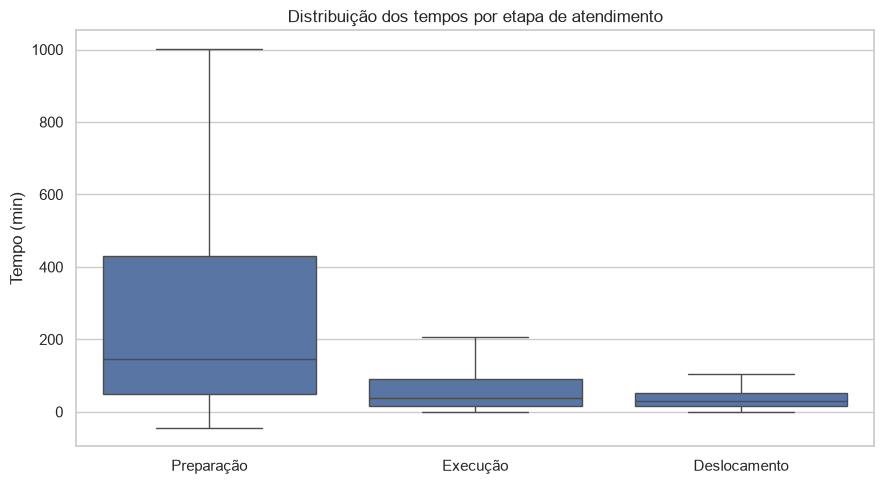

In [26]:
query_tempos = """
SELECT
    mda_preparo AS tempo_preparacao,
    mda_deslocamento AS tempo_deslocamento,
    mda_execucao AS tempo_execucao
FROM staging.ocorrencias_emergenciais
"""
df_tempos = pd.read_sql_query(query_tempos, engine)

nomes_etapas = {
    "tempo_preparacao": "Preparação",
    "tempo_deslocamento": "Deslocamento",
    "tempo_execucao": "Execução",
}
df_tempos = df_tempos.rename(columns=nomes_etapas)
for coluna in nomes_etapas.values():
    df_tempos[coluna] = pd.to_numeric(df_tempos[coluna], errors="coerce")

resumo_tempos = (
    df_tempos.describe(percentiles=[0.25, 0.50, 0.75])
    .T.loc[:, ["count", "mean", "25%", "50%", "75%"]]
    .rename(columns={
        "count": "Registros válidos",
        "mean": "Média (min)",
        "25%": "Q1 (min)",
        "50%": "Mediana (min)",
        "75%": "Q3 (min)",
    })
    .sort_values("Mediana (min)", ascending=False)
)
resumo_tempos.index.name = "Etapa"
display(resumo_tempos.round(2))

ordem_etapas = resumo_tempos.index.tolist()
df_tempos_grafico = df_tempos.melt(
    var_name="Etapa", value_name="Tempo (min)"
).dropna()

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_tempos_grafico,
    x="Etapa",
    y="Tempo (min)",
    order=ordem_etapas,
    showfliers=False,
)
plt.title("Distribuição dos tempos por etapa de atendimento")
plt.xlabel("")
plt.ylabel("Tempo (min)")
plt.tight_layout()
plt.show()

Entre os resultados, a preparação tem a maior mediana (144,52 min), seguida da execução (37,30 min) e do deslocamento (31,08 min).

### Outliers de deslocamento por município

Consideramos outlier o tempo de deslocamento acima de `Q3 + 1,5 × IQR`, calculado sobre os tempos positivos válidos. A tabela compara municípios com pelo menos 30 registros, mostrando quantidade e percentual de outliers para evidenciar dificuldades logísticas sem priorizar localidades com amostras muito pequenas.

Considerei outlier um deslocamento positivo acima de 105,77 minutos, limite global calculado por Q3 + 1,5 × IQR. A tabela e o gráfico comparam os municípios com pelo menos 30 registros, incluindo quantidade e proporção de outliers.

Limite superior global de outlier: 105.77 min
Municípios com pelo menos 30 registros: 186


,cod_municipio_ibge,municipio,registros_validos,mediana_deslocamento_min,maior_deslocamento_min,qtd_outliers,percentual_outliers
0,2612554,Santa Filomena,3301,65.12,567.52,886,26.84%
1,2609154,Manari,2726,55.45,441.27,722,26.49%
2,2614303,Moreilândia,2546,63.99,418.98,646,25.37%
3,2603926,Carnaubeira da Penha,2375,63.82,505.05,562,23.66%
4,2603009,Cabrobó,5743,62.97,645.75,1286,22.39%
5,2615805,Tupanatinga,4766,60.41,542.48,1042,21.86%
6,2607000,Inajá,5280,50.28,621.07,1055,19.98%
7,2601607,Belém do São Francisco,5606,58.43,1451.23,1107,19.75%
8,2614105,Sertânia,8497,61.47,543.93,1662,19.56%
9,2610400,Parnamirim,4535,63.10,545.57,881,19.43%


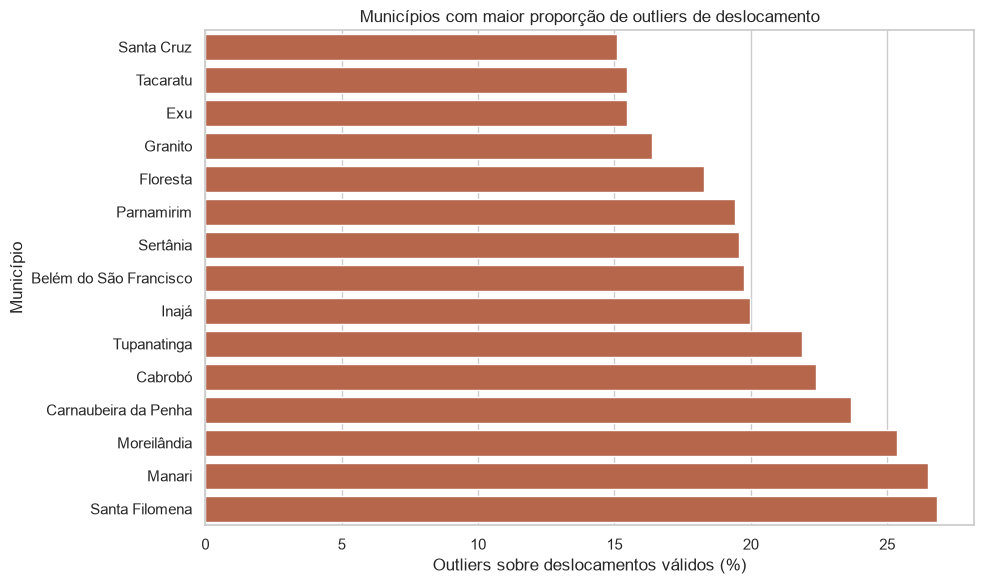

In [27]:
query_deslocamentos_municipio = """
SELECT
    oe.cod_ibge AS cod_municipio_ibge,
    COALESCE(NULLIF(m.nome_municipio, ''), 'Município sem nome') AS municipio,
    oe.mda_deslocamento AS tempo_deslocamento
FROM staging.ocorrencias_emergenciais AS oe
LEFT JOIN dados.municipio AS m
    ON m.id_municipio = oe.cod_ibge
WHERE oe.cod_ibge IS NOT NULL
  AND oe.mda_deslocamento IS NOT NULL
"""
df_deslocamentos_municipio = pd.read_sql_query(
    query_deslocamentos_municipio, engine
)
df_deslocamentos_municipio["tempo_deslocamento"] = pd.to_numeric(
    df_deslocamentos_municipio["tempo_deslocamento"], errors="coerce"
)
df_deslocamentos_municipio = df_deslocamentos_municipio.dropna(
    subset=["tempo_deslocamento"]
)
df_deslocamentos_municipio = df_deslocamentos_municipio.loc[
    df_deslocamentos_municipio["tempo_deslocamento"] > 0
].copy()

q1, q3 = df_deslocamentos_municipio["tempo_deslocamento"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_outlier_deslocamento = q3 + 1.5 * iqr
df_deslocamentos_municipio["outlier"] = (
    df_deslocamentos_municipio["tempo_deslocamento"]
    > limite_outlier_deslocamento
)

resumo_municipios = (
    df_deslocamentos_municipio.groupby(
        ["cod_municipio_ibge", "municipio"], as_index=False
    )
    .agg(
        registros_validos=("tempo_deslocamento", "size"),
        mediana_deslocamento_min=("tempo_deslocamento", "median"),
        maior_deslocamento_min=("tempo_deslocamento", "max"),
        qtd_outliers=("outlier", "sum"),
    )
)
resumo_municipios["percentual_outliers"] = (
    100 * resumo_municipios["qtd_outliers"]
    / resumo_municipios["registros_validos"]
)
MIN_REGISTROS_MUNICIPIO = 30
resumo_municipios = (
    resumo_municipios.loc[
        resumo_municipios["registros_validos"] >= MIN_REGISTROS_MUNICIPIO
    ]
    .sort_values(
        ["percentual_outliers", "qtd_outliers"], ascending=False
    )
    .reset_index(drop=True)
)

print(f"Limite superior global de outlier: {limite_outlier_deslocamento:.2f} min")
print(f"Municípios com pelo menos {MIN_REGISTROS_MUNICIPIO} registros: {len(resumo_municipios)}")
display(
    resumo_municipios.head(20).style.format({
        "mediana_deslocamento_min": "{:.2f}",
        "maior_deslocamento_min": "{:.2f}",
        "percentual_outliers": "{:.2f}%",
    })
)

if not resumo_municipios.empty:
    top_municipios = resumo_municipios.head(15).sort_values(
        "percentual_outliers", ascending=True
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_municipios,
        x="percentual_outliers",
        y="municipio",
        color="#c65d3a",
    )
    plt.title("Municípios com maior proporção de outliers de deslocamento")
    plt.xlabel("Outliers sobre deslocamentos válidos (%)")
    plt.ylabel("Município")
    plt.tight_layout()
    plt.show()

### Severidade e impacto ao consumidor

Cada linha de `staging.interrupcoes` será tratada como um evento. Para impactos positivos, as faixas de severidade são definidas pela distribuição observada: até P50 (baixa), P50–P75 (moderada), P75–P95 (alta) e acima de P95 (crítica). Valores zero e ausentes são destacados separadamente. As faixas são relativas aos dados analisados, não limites regulatórios.

In [30]:
import numpy as np

query_severidade = """
WITH interrupcoes_com_chave AS (
    SELECT
        i.ano_arquivo_origem,
        i.num_ordem_interrupcao,
        i.num_unidade_consumidora AS consumidores_afetados,
        NULLIF(
            split_part(COALESCE(i.num_ordem_interrupcao, ''), '_', 1),
            ''
        ) AS codigo_ocorrencia
    FROM staging.interrupcoes AS i
)
SELECT
    i.ano_arquivo_origem,
    i.num_ordem_interrupcao AS evento,
    i.consumidores_afetados,
    oe.cod_ibge AS cod_municipio_ibge,
    COALESCE(NULLIF(m.nome_municipio, ''), 'Município não identificado') AS municipio
FROM interrupcoes_com_chave AS i
LEFT JOIN LATERAL (
    SELECT o.cod_ibge
    FROM staging.ocorrencias_emergenciais AS o
    WHERE o.ano_arquivo_origem = i.ano_arquivo_origem
      AND o.num_ocorrencia = i.codigo_ocorrencia
    ORDER BY o.dth_inicio_ocorrencia_aberta NULLS LAST
    LIMIT 1
) AS oe ON TRUE
LEFT JOIN dados.municipio AS m
    ON m.id_municipio = oe.cod_ibge
"""
df_severidade = pd.read_sql_query(query_severidade, engine)
df_severidade["consumidores_afetados"] = pd.to_numeric(
    df_severidade["consumidores_afetados"], errors="coerce"
)
df_severidade.loc[
    df_severidade["consumidores_afetados"] < 0, "consumidores_afetados"
] = np.nan

impactos_positivos = df_severidade.loc[
    df_severidade["consumidores_afetados"] > 0, "consumidores_afetados"
]
p50, p75, p95 = impactos_positivos.quantile([0.50, 0.75, 0.95])
impacto = df_severidade["consumidores_afetados"]
condicoes_severidade = [
    impacto.isna(),
    impacto.eq(0),
    impacto.le(p50),
    impacto.le(p75),
    impacto.le(p95),
]
rotulos_severidade = [
    "Sem dado",
    "Sem impacto",
    "Baixa",
    "Moderada",
    "Alta",
]
df_severidade["severidade"] = np.select(
    condicoes_severidade, rotulos_severidade, default="Crítica"
)

ordem_severidade = ["Crítica", "Alta", "Moderada", "Baixa", "Sem impacto", "Sem dado"]
resumo_severidade = (
    df_severidade.groupby("severidade")
    .agg(
        eventos=("evento", "size"),
        consumidores_afetados_somados=("consumidores_afetados", "sum"),
        mediana_consumidores=("consumidores_afetados", "median"),
    )
    .reindex(ordem_severidade)
)
for coluna in ("eventos", "consumidores_afetados_somados"):
    resumo_severidade[coluna] = resumo_severidade[coluna].fillna(0)
resumo_severidade["eventos"] = resumo_severidade["eventos"].astype(int)
resumo_severidade["percentual_eventos"] = (
    100 * resumo_severidade["eventos"] / len(df_severidade)
)
print(
    f"Faixas calculadas entre eventos com impacto positivo: "
    f"P50={p50:.0f}, P75={p75:.0f}, P95={p95:.0f} UCs"
)
display(resumo_severidade.style.format({
    "eventos": "{:,.0f}",
    "consumidores_afetados_somados": "{:,.0f}",
    "mediana_consumidores": "{:,.0f}",
    "percentual_eventos": "{:.2f}%",
}, na_rep="—"))

chaves_municipio = ["cod_municipio_ibge", "municipio"]
resumo_impacto_municipio = (
    df_severidade.groupby(chaves_municipio, dropna=False)
    .agg(
        eventos_totais=("evento", "size"),
        consumidores_somados=("consumidores_afetados", "sum"),
    )
)
eventos_altos_criticos = df_severidade.loc[
    df_severidade["severidade"].isin(["Alta", "Crítica"])
]
impacto_alto_critico_municipio = (
    eventos_altos_criticos.groupby(chaves_municipio, dropna=False)
    .agg(
        eventos_altos_criticos=("evento", "size"),
        consumidores_em_eventos_severos=("consumidores_afetados", "sum"),
    )
)
resumo_impacto_municipio = resumo_impacto_municipio.join(
    impacto_alto_critico_municipio, how="left"
).fillna({
    "eventos_altos_criticos": 0,
    "consumidores_em_eventos_severos": 0,
})
resumo_impacto_municipio["percentual_eventos_altos_criticos"] = (
    100 * resumo_impacto_municipio["eventos_altos_criticos"]
    / resumo_impacto_municipio["eventos_totais"]
)
resumo_impacto_municipio = resumo_impacto_municipio.sort_values(
    ["consumidores_em_eventos_severos", "eventos_altos_criticos"],
    ascending=False,
)
display(resumo_impacto_municipio.head(20).style.format({
    "eventos_totais": "{:,.0f}",
    "consumidores_somados": "{:,.0f}",
    "eventos_altos_criticos": "{:,.0f}",
    "consumidores_em_eventos_severos": "{:,.0f}",
    "percentual_eventos_altos_criticos": "{:.2f}%",
}))

colunas_evento = [
    "ano_arquivo_origem",
    "evento",
    "cod_municipio_ibge",
    "municipio",
    "consumidores_afetados",
    "severidade",
]
display(
    df_severidade.loc[df_severidade["severidade"] == "Crítica", colunas_evento]
    .sort_values("consumidores_afetados", ascending=False)
    .head(20)
)

Faixas calculadas entre eventos com impacto positivo: P50=1, P75=23, P95=387 UCs


,eventos,consumidores_afetados_somados,mediana_consumidores,percentual_eventos
severidade,,,,
Crítica,"64,273","102,621,570",931,4.99%
Alta,"257,315","31,491,906",92,19.97%
Moderada,"250,671","2,150,276",7,19.46%
Baixa,"716,063","716,063",1,55.58%
Sem impacto,0,0,—,0.00%
Sem dado,0,0,—,0.00%


,,eventos_totais,consumidores_somados,eventos_altos_criticos,consumidores_em_eventos_severos,percentual_eventos_altos_criticos
cod_municipio_ibge,municipio,,,,,
nan,Município não identificado,"92,344","28,242,116","39,144","28,037,409",42.39%
2611606,Recife,"141,896","15,802,209","29,946","15,634,968",21.10%
2607901,Jaboatão dos Guararapes,"60,037","4,735,990","9,449","4,664,642",15.74%
2604106,Caruaru,"38,560","4,203,690","7,697","4,139,728",19.96%
2611101,Petrolina,"44,553","4,036,583","10,352","3,937,219",23.24%
2602902,Cabo de Santo Agostinho,"34,835","3,722,457","8,539","3,661,950",24.51%
2609600,Olinda,"37,842","3,580,922","7,329","3,538,966",19.37%
2610707,Paulista,"33,728","3,302,665","6,201","3,261,061",18.39%
2616407,Vitória de Santo Antão,"22,696","2,075,075","4,961","2,027,643",21.86%


,ano_arquivo_origem,evento,cod_municipio_ibge,municipio,consumidores_afetados,severidade
782255,2024,19105418_17984889,2604106,Caruaru,17657.0,Crítica
782596,2024,19105418_17985778,2604106,Caruaru,17651.0,Crítica
782321,2024,19105418_17985065,2604106,Caruaru,17651.0,Crítica
928855,2025,19464025_18395577,2601706,Belo Jardim,17639.0,Crítica
1058337,2025,19806353_18767203,2604106,Caruaru,17581.0,Crítica
599371,2023,18489955_17481264,2604106,Caruaru,17466.0,Crítica
812620,2024,19181835_18072083,NaN,Município não identificado,17132.0,Crítica
94472,2021,17098322_15975652,NaN,Município não identificado,17129.0,Crítica
254028,2022,17536046_16454218,2611101,Petrolina,15721.0,Crítica
782241,2024,19105418_17984880,2604106,Caruaru,15715.0,Crítica


### Ranking de criticidade da infraestrutura

Cruzo a quantidade de unidades consumidoras afetadas com as descrições de subestação e alimentador disponíveis no staging. Como os códigos `CodSubestacao` e `CodAlimentador` não existem nas fontes carregadas, uso `DscSubestacaoDistribuicao` e `DscAlimentadorSubestacao` como identificadores; eventos sem essas descrições ficam fora dos rankings. A prioridade é ordenada pelo total de UCs afetadas em eventos de severidade alta ou crítica, com volume de eventos e participação severa para contextualizar.

Eventos carregados: 1,288,322; com subestação identificada: 1,109,874; com alimentador identificado: 1,109,874
Subestações prioritárias por UCs afetadas em eventos altos/críticos:


,subestacao,interrupcoes,ucs_afetadas_somadas,eventos_altos_criticos,ucs_em_eventos_severos,mediana_ucs_por_evento,percentual_eventos_altos_criticos
0,PAU AMARELO,"17,107","2,474,006","3,327","2,454,301",1,19.45%
1,SAO BENEDITO,"18,249","2,357,148","4,504","2,334,862",1,24.68%
2,CAMPUS,"15,883","2,043,917","3,349","2,017,155",1,21.09%
3,LAJEDO,"18,406","2,028,484","4,448","1,975,742",2,24.17%
4,VITORIA DE SANTO ANTAO,"16,669","1,960,574","3,676","1,927,143",1,22.05%
5,BOM JARDIM,"14,782","1,976,050","4,426","1,923,867",7,29.94%
6,PALMARES,"11,539","1,883,569","3,724","1,859,700",2,32.27%
7,IBURA,"14,682","1,864,556","2,619","1,848,575",1,17.84%
8,SANTA CRUZ DO CAPIBARIBE,"12,011","1,770,073","2,392","1,752,508",1,19.92%
9,ARARIPINA,"12,839","1,643,643","3,223","1,603,746",3,25.10%


Alimentadores prioritários por UCs afetadas em eventos altos/críticos:


,alimentador,interrupcoes,ucs_afetadas_somadas,eventos_altos_criticos,ucs_em_eventos_severos,mediana_ucs_por_evento,percentual_eventos_altos_criticos
0,LJD-01L2,"5,830","761,551","1,435","742,246",4,24.61%
1,VCA-01C2,"3,259","633,196",795,"623,601",1,24.39%
2,GVD-01J5,"3,920","602,919","1,169","590,869",5,29.82%
3,BJD-01C5,"4,367","584,776","1,364","569,826",7,31.23%
4,VSA-01C2,"5,174","566,285","1,272","550,834",2,24.58%
5,STC-01C7,"1,726","544,952",417,"542,664",1,24.16%
6,CAA-01C2,"2,555","545,433",610,"541,438",1,23.87%
7,TDD-01C5,"2,246","526,910",686,"519,420",6,30.54%
8,VSA-01C4,"3,456","513,235",797,"506,424",1,23.06%
9,ORT-01L2,"3,990","503,700",975,"494,139",1,24.44%


Combinações subestação-alimentador prioritárias:


,subestacao,alimentador,interrupcoes,ucs_afetadas_somadas,eventos_altos_criticos,ucs_em_eventos_severos,mediana_ucs_por_evento,percentual_eventos_altos_criticos
0,LAJEDO,LJD-01L2,"5,830","761,551","1,435","742,246",4,24.61%
1,VICENCIA,VCA-01C2,"3,259","633,196",795,"623,601",1,24.39%
2,GRAVATA II,GVD-01J5,"3,920","602,919","1,169","590,869",5,29.82%
3,BOM JARDIM,BJD-01C5,"4,367","584,776","1,364","569,826",7,31.23%
4,VITORIA DE SANTO ANTAO,VSA-01C2,"5,174","566,285","1,272","550,834",2,24.58%
5,SANTA CRUZ DO CAPIBARIBE,STC-01C7,"1,726","544,952",417,"542,664",1,24.16%
6,CARUARU,CAA-01C2,"2,555","545,433",610,"541,438",1,23.87%
7,TRINDADE,TDD-01C5,"2,246","526,910",686,"519,420",6,30.54%
8,VITORIA DE SANTO ANTAO,VSA-01C4,"3,456","513,235",797,"506,424",1,23.06%
9,ORATORIO (ENERGISA),ORT-01L2,"3,990","503,700",975,"494,139",1,24.44%


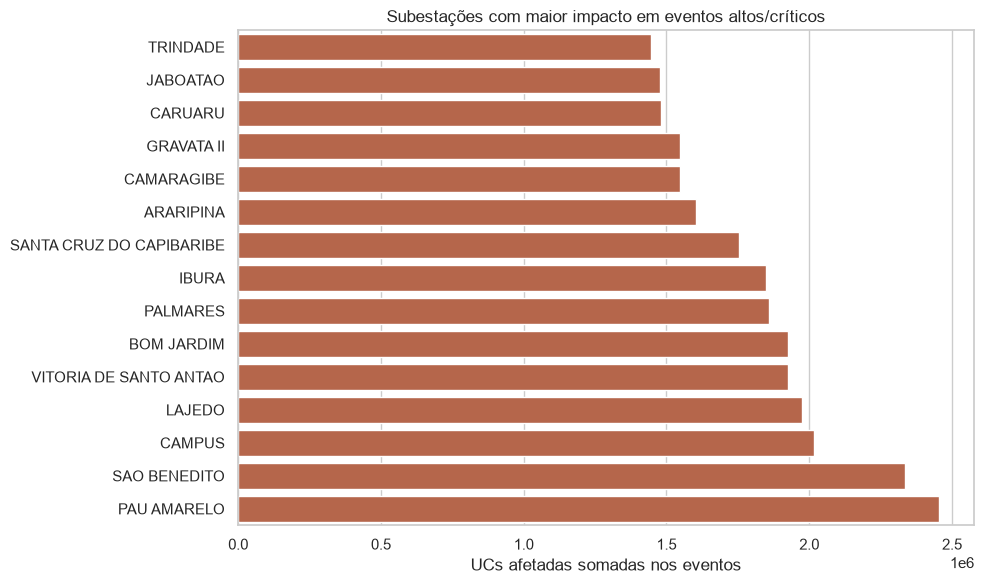

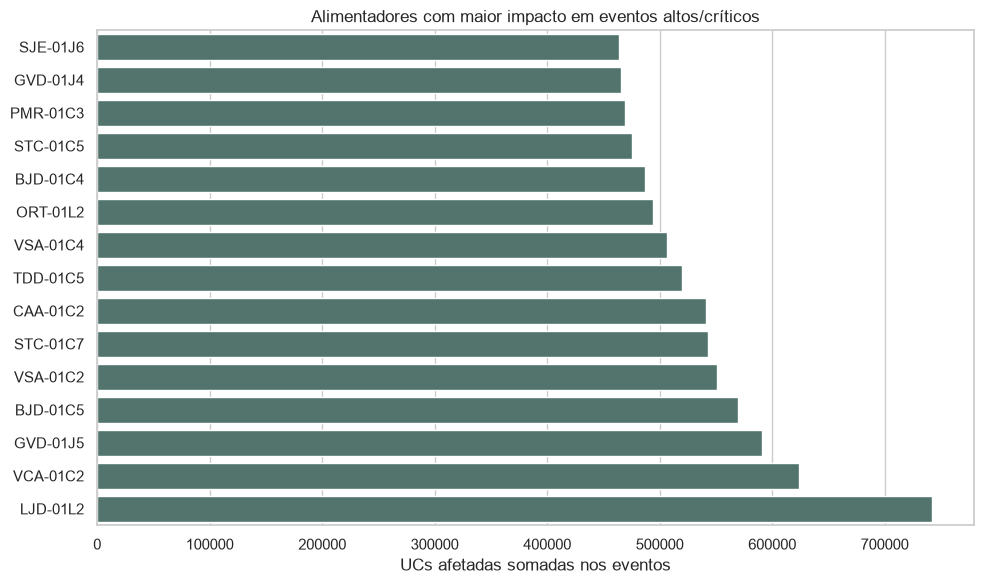

In [31]:
query_impacto_infraestrutura = """
SELECT
    ano_arquivo_origem,
    num_ordem_interrupcao AS evento,
    dsc_subestacao_distribuicao AS subestacao,
    dsc_alimentador_subestacao AS alimentador,
    num_unidade_consumidora AS consumidores_afetados
FROM staging.interrupcoes
"""
df_impacto_infraestrutura = pd.read_sql_query(
    query_impacto_infraestrutura, engine
)
df_impacto_infraestrutura["consumidores_afetados"] = pd.to_numeric(
    df_impacto_infraestrutura["consumidores_afetados"], errors="coerce"
)
df_impacto_infraestrutura.loc[
    df_impacto_infraestrutura["consumidores_afetados"] < 0,
    "consumidores_afetados",
] = np.nan

for coluna in ("subestacao", "alimentador"):
    df_impacto_infraestrutura[coluna] = (
        df_impacto_infraestrutura[coluna]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

impacto_infra = df_impacto_infraestrutura["consumidores_afetados"]
df_impacto_infraestrutura["severidade"] = np.select(
    [
        impacto_infra.isna(),
        impacto_infra.eq(0),
        impacto_infra.le(p50),
        impacto_infra.le(p75),
        impacto_infra.le(p95),
    ],
    ["Sem dado", "Sem impacto", "Baixa", "Moderada", "Alta"],
    default="Crítica",
)
df_impacto_infraestrutura["evento_alto_critico"] = (
    df_impacto_infraestrutura["severidade"].isin(["Alta", "Crítica"])
)
df_impacto_infraestrutura["ucs_em_eventos_severos"] = (
    df_impacto_infraestrutura["consumidores_afetados"].where(
        df_impacto_infraestrutura["evento_alto_critico"], 0
    )
)

print(
    f"Eventos carregados: {len(df_impacto_infraestrutura):,}; "
    f"com subestação identificada: {df_impacto_infraestrutura['subestacao'].notna().sum():,}; "
    f"com alimentador identificado: {df_impacto_infraestrutura['alimentador'].notna().sum():,}"
)


def ranquear_infraestrutura(df, dimensoes):
    base = df.dropna(subset=dimensoes)
    ranking = (
        base.groupby(dimensoes, as_index=False, dropna=False)
        .agg(
            interrupcoes=("evento", "size"),
            ucs_afetadas_somadas=("consumidores_afetados", "sum"),
            eventos_altos_criticos=("evento_alto_critico", "sum"),
            ucs_em_eventos_severos=("ucs_em_eventos_severos", "sum"),
            mediana_ucs_por_evento=("consumidores_afetados", "median"),
        )
    )
    ranking["percentual_eventos_altos_criticos"] = (
        100 * ranking["eventos_altos_criticos"] / ranking["interrupcoes"]
    )
    return ranking.sort_values(
        ["ucs_em_eventos_severos", "eventos_altos_criticos"],
        ascending=False,
    ).reset_index(drop=True)


ranking_subestacoes = ranquear_infraestrutura(
    df_impacto_infraestrutura, ["subestacao"]
)
ranking_alimentadores = ranquear_infraestrutura(
    df_impacto_infraestrutura, ["alimentador"]
)
ranking_subestacao_alimentador = ranquear_infraestrutura(
    df_impacto_infraestrutura, ["subestacao", "alimentador"]
)

formatacao_ranking = {
    "interrupcoes": "{:,.0f}",
    "ucs_afetadas_somadas": "{:,.0f}",
    "eventos_altos_criticos": "{:,.0f}",
    "ucs_em_eventos_severos": "{:,.0f}",
    "mediana_ucs_por_evento": "{:,.0f}",
    "percentual_eventos_altos_criticos": "{:.2f}%",
}
print("Subestações prioritárias por UCs afetadas em eventos altos/críticos:")
display(ranking_subestacoes.head(20).style.format(formatacao_ranking))
print("Alimentadores prioritários por UCs afetadas em eventos altos/críticos:")
display(ranking_alimentadores.head(20).style.format(formatacao_ranking))
print("Combinações subestação-alimentador prioritárias:")
display(ranking_subestacao_alimentador.head(20).style.format(formatacao_ranking))

for ranking, coluna, titulo, cor in [
    (ranking_subestacoes, "subestacao", "Subestações", "#c65d3a"),
    (ranking_alimentadores, "alimentador", "Alimentadores", "#4c7a70"),
]:
    top_infra = ranking.head(15).sort_values(
        "ucs_em_eventos_severos", ascending=True
    )
    if not top_infra.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=top_infra,
            x="ucs_em_eventos_severos",
            y=coluna,
            color=cor,
        )
        plt.title(f"{titulo} com maior impacto em eventos altos/críticos")
        plt.xlabel("UCs afetadas somadas nos eventos")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

### Padrões causais e sazonais (2021–2025)

A análise exclui 2026. Nos arquivos de 2021–2025, os quatro níveis de causa estão concatenados: `DscFatoGeradorInterrupcao` usa ` - ` em Interrupções e `DscOcorrenciaAberta` usa `;` em Ocorrências Emergenciais. Os níveis são reconstruídos desses campos, e ano/mês são extraídos das datas de início, pois `NumAnoCompetencia` e `NumMesCompetencia` não estão disponíveis nesses schemas. As bases são analisadas separadamente, sem somar eventos de granularidades diferentes.

Causas mais frequentes por base no período 2021–2025:


,fonte,origem,tipo,causa,detalhe,eventos,participacao_fonte_pct
24,Interrupções,INTERNO,NAO PROGRAMADA,PROPRIAS DO SISTEMA,FALHA DE MATERIAL OU EQUIPAMENTO,"337,323",30.39%
19,Interrupções,INTERNO,NAO PROGRAMADA,MEIO AMBIENTE,VENTO,"110,712",9.98%
13,Interrupções,INTERNO,NAO PROGRAMADA,MEIO AMBIENTE,ARVORE OU VEGETACAO,"101,935",9.18%
33,Interrupções,INTERNO,NAO PROGRAMADA,TERCEIROS,INTERFERENCIA DE TERCEIROS,"96,183",8.67%
32,Interrupções,INTERNO,NAO PROGRAMADA,TERCEIROS,DEFEITO INTERNO NAO AFETANDO OUTRAS UNIDADES CONSU,"93,201",8.40%
15,Interrupções,INTERNO,NAO PROGRAMADA,MEIO AMBIENTE,DESCARGA ATMOSFERICA,"67,245",6.06%
12,Interrupções,INTERNO,NAO PROGRAMADA,MEIO AMBIENTE,ANIMAIS,"49,691",4.48%
18,Interrupções,INTERNO,NAO PROGRAMADA,MEIO AMBIENTE,QUEIMADA OU INCENDIO,"49,159",4.43%
26,Interrupções,INTERNO,NAO PROGRAMADA,PROPRIAS DO SISTEMA,SOBRECARGA,"25,719",2.32%
21,Interrupções,INTERNO,NAO PROGRAMADA,NAO CLASSIFICADA,Não informado,"22,848",2.06%


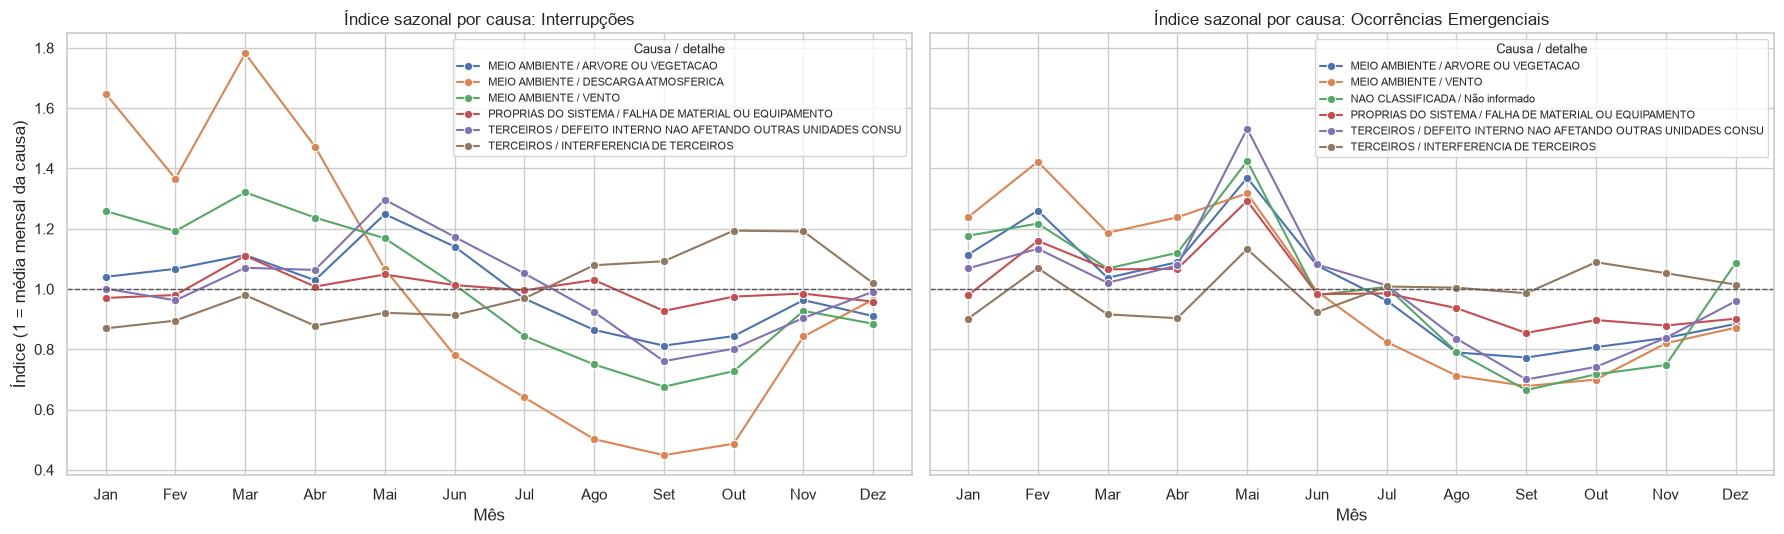

In [33]:
import numpy as np

query_causas_sazonais = """
WITH eventos AS (
    SELECT
        'Interrupções'::text AS fonte,
        EXTRACT(YEAR FROM dat_inicio_interrupcao)::int AS ano,
        EXTRACT(MONTH FROM dat_inicio_interrupcao)::int AS mes,
        split_part(COALESCE(dsc_fato_gerador_interrupcao, ''), ' - ', 1) AS origem,
        split_part(COALESCE(dsc_fato_gerador_interrupcao, ''), ' - ', 2) AS tipo,
        split_part(COALESCE(dsc_fato_gerador_interrupcao, ''), ' - ', 3) AS causa,
        split_part(COALESCE(dsc_fato_gerador_interrupcao, ''), ' - ', 4) AS detalhe
    FROM staging.interrupcoes
    WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
      AND dat_inicio_interrupcao IS NOT NULL

    UNION ALL

    SELECT
        'Ocorrências Emergenciais'::text AS fonte,
        EXTRACT(YEAR FROM dth_inicio_ocorrencia_aberta)::int AS ano,
        EXTRACT(MONTH FROM dth_inicio_ocorrencia_aberta)::int AS mes,
        split_part(COALESCE(dsc_ocorrencia_aberta, ''), ';', 1) AS origem,
        split_part(COALESCE(dsc_ocorrencia_aberta, ''), ';', 2) AS tipo,
        split_part(COALESCE(dsc_ocorrencia_aberta, ''), ';', 3) AS causa,
        split_part(COALESCE(dsc_ocorrencia_aberta, ''), ';', 4) AS detalhe
    FROM staging.ocorrencias_emergenciais
    WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
      AND dth_inicio_ocorrencia_aberta IS NOT NULL
)
SELECT
    fonte,
    ano,
    mes,
    COALESCE(NULLIF(BTRIM(origem), ''), 'Não informado') AS origem,
    COALESCE(NULLIF(BTRIM(tipo), ''), 'Não informado') AS tipo,
    COALESCE(NULLIF(BTRIM(causa), ''), 'Não informado') AS causa,
    COALESCE(NULLIF(BTRIM(detalhe), ''), 'Não informado') AS detalhe,
    COUNT(*) AS eventos
FROM eventos
WHERE ano BETWEEN 2021 AND 2025
GROUP BY fonte, ano, mes, origem, tipo, causa, detalhe
"""
df_causas_mensais = pd.read_sql_query(query_causas_sazonais, engine)
if df_causas_mensais.empty:
    raise ValueError("Não foram encontrados eventos datados entre 2021 e 2025.")

niveis_causais = ["origem", "tipo", "causa", "detalhe"]
chaves_causais = ["fonte", *niveis_causais]
df_causas_mensais["arvore_causal"] = (
    df_causas_mensais[niveis_causais].astype(str).agg(" / ".join, axis=1)
)

frequencia_causas = (
    df_causas_mensais.groupby(chaves_causais + ["arvore_causal"], as_index=False)
    .agg(eventos=("eventos", "sum"))
)
total_eventos_fonte = frequencia_causas.groupby("fonte")["eventos"].transform("sum")
frequencia_causas["participacao_fonte_pct"] = (
    100 * frequencia_causas["eventos"] / total_eventos_fonte
)
frequencia_causas = frequencia_causas.sort_values(
    ["fonte", "eventos"], ascending=[True, False]
)
frequencia_causas["ranking"] = frequencia_causas.groupby("fonte").cumcount() + 1
print("Causas mais frequentes por base no período 2021–2025:")
display(
    frequencia_causas.loc[frequencia_causas["ranking"] <= 10, [
        "fonte", "origem", "tipo", "causa", "detalhe", "eventos",
        "participacao_fonte_pct",
    ]].style.format({
        "eventos": "{:,.0f}",
        "participacao_fonte_pct": "{:.2f}%",
    })
)

# Normaliza cada causa dentro de cada ano para destacar sazonalidade, não variação de volume anual.
top_causas_sazonais = frequencia_causas.groupby("fonte", group_keys=False).head(6)
anos_fonte = df_causas_mensais[["fonte", "ano"]].drop_duplicates()
meses = pd.DataFrame({"mes": range(1, 13), "chave_grade": 1})
grade_sazonal = (
    top_causas_sazonais[["fonte", "arvore_causal"]]
    .merge(anos_fonte, on="fonte")
    .drop_duplicates()
    .assign(chave_grade=1)
    .merge(meses, on="chave_grade")
    .drop(columns="chave_grade")
)
contagem_mensal_causas = (
    df_causas_mensais.groupby(
        ["fonte", "ano", "mes", "arvore_causal"], as_index=False
    )
    .agg(eventos=("eventos", "sum"))
)
grade_sazonal = grade_sazonal.merge(
    contagem_mensal_causas,
    on=["fonte", "ano", "mes", "arvore_causal"],
    how="left",
)
grade_sazonal["eventos"] = grade_sazonal["eventos"].fillna(0)
total_causa_ano = grade_sazonal.groupby(
    ["fonte", "arvore_causal", "ano"]
)["eventos"].transform("sum")
grade_sazonal["indice_sazonal"] = np.where(
    total_causa_ano > 0,
    grade_sazonal["eventos"] / total_causa_ano * 12,
    np.nan,
)
indice_sazonal_mensal = (
    grade_sazonal.groupby(["fonte", "arvore_causal", "mes"], as_index=False)
    .agg(indice_sazonal_medio=("indice_sazonal", "mean"))
)

# Usa causa e detalhe nas legendas para manter os gráficos legíveis.
indice_sazonal_mensal["rotulo_causal"] = indice_sazonal_mensal[
    "arvore_causal"
].map(lambda arvore: " / ".join(arvore.split(" / ")[-2:]))
fontes = indice_sazonal_mensal["fonte"].drop_duplicates().tolist()
fig, axes = plt.subplots(
    1, len(fontes), figsize=(9 * len(fontes), 5.5), squeeze=False, sharey=True
)
rotulos_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
for eixo, fonte in zip(axes.ravel(), fontes):
    dados_fonte = indice_sazonal_mensal.loc[
        indice_sazonal_mensal["fonte"] == fonte
    ]
    sns.lineplot(
        data=dados_fonte,
        x="mes",
        y="indice_sazonal_medio",
        hue="rotulo_causal",
        marker="o",
        ax=eixo,
    )
    eixo.axhline(1, color="#555555", linestyle="--", linewidth=1)
    eixo.set_title(f"Índice sazonal por causa: {fonte}")
    eixo.set_xlabel("Mês")
    eixo.set_ylabel("Índice (1 = média mensal da causa)")
    eixo.set_xticks(range(1, 13), labels=rotulos_meses)
    eixo.tick_params(axis="x", rotation=0)
    eixo.legend(title="Causa / detalhe", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
nomes_meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez",
}
indices_validos = indice_sazonal_mensal.dropna(subset=["indice_sazonal_medio"])
indices_pico = indices_validos.groupby(
    ["fonte", "arvore_causal"]
)["indice_sazonal_medio"].idxmax()
picos_causais = indices_validos.loc[indices_pico].copy()
picos_causais["mes_pico"] = picos_causais["mes"].map(nomes_meses)
picos_causais = picos_causais.merge(
    frequencia_causas[["fonte", "arvore_causal", "eventos"]],
    on=["fonte", "arvore_causal"],
    how="left",
).sort_values(["fonte", "indice_sazonal_medio"], ascending=[True, False])
print("Mês de maior concentração relativa para cada causa exibida no gráfico:")
display(picos_causais[[
    "fonte", "arvore_causal", "mes_pico", "indice_sazonal_medio", "eventos"
]].style.format({
    "indice_sazonal_medio": "{:.2f}",
    "eventos": "{:,.0f}",
}))

Mês de maior concentração relativa para cada causa exibida no gráfico:


,fonte,arvore_causal,mes_pico,indice_sazonal_medio,eventos
1,Interrupções,INTERNO / NAO PROGRAMADA / MEIO AMBIENTE / DESCARGA ATMOSFERICA,Mar,1.78,"67,245"
2,Interrupções,INTERNO / NAO PROGRAMADA / MEIO AMBIENTE / VENTO,Mar,1.32,"110,712"
4,Interrupções,INTERNO / NAO PROGRAMADA / TERCEIROS / DEFEITO INTERNO NAO AFETANDO OUTRAS UNIDADES CONSU,Mai,1.30,"93,201"
0,Interrupções,INTERNO / NAO PROGRAMADA / MEIO AMBIENTE / ARVORE OU VEGETACAO,Mai,1.25,"101,935"
5,Interrupções,INTERNO / NAO PROGRAMADA / TERCEIROS / INTERFERENCIA DE TERCEIROS,Out,1.19,"96,183"
3,Interrupções,INTERNO / NAO PROGRAMADA / PROPRIAS DO SISTEMA / FALHA DE MATERIAL OU EQUIPAMENTO,Mar,1.11,"337,323"
10,Ocorrências Emergenciais,INTERNA / NAO PROGRAMADA / TERCEIROS / DEFEITO INTERNO NAO AFETANDO OUTRAS UNIDADES CONSU,Mai,1.53,"123,652"
8,Ocorrências Emergenciais,INTERNA / NAO PROGRAMADA / NAO CLASSIFICADA / Não informado,Mai,1.42,"459,499"
7,Ocorrências Emergenciais,INTERNA / NAO PROGRAMADA / MEIO AMBIENTE / VENTO,Fev,1.42,"117,214"
6,Ocorrências Emergenciais,INTERNA / NAO PROGRAMADA / MEIO AMBIENTE / ARVORE OU VEGETACAO,Mai,1.37,"141,873"


Entre as interrupções, falha de material ou equipamento lidera, com 337.323 registros (30,39%); entre as ocorrências emergenciais, essa causa soma 435.299 (23,60%), enquanto 459.499 registros (24,91%) estão como “não classificada”. Árvore ou vegetação aparece em 101.935 interrupções e 141.873 ocorrências.

O padrão sazonal aponta pico de descargas atmosféricas em março nas interrupções (índice 1,78, sendo 1 a média mensal da causa) e pico de árvore ou vegetação em maio nas duas bases. Isso indica meses de maior concentração relativa, mas não demonstra que chuva seja a causa; essa hipótese exige cruzamento com dados climáticos.

## Painel geral da EDA (2021–2025)

Resumo visual das bases, com as métricas distribuídas em nove gráficos. O ano de 2026 permanece excluído por incompletude de campos.

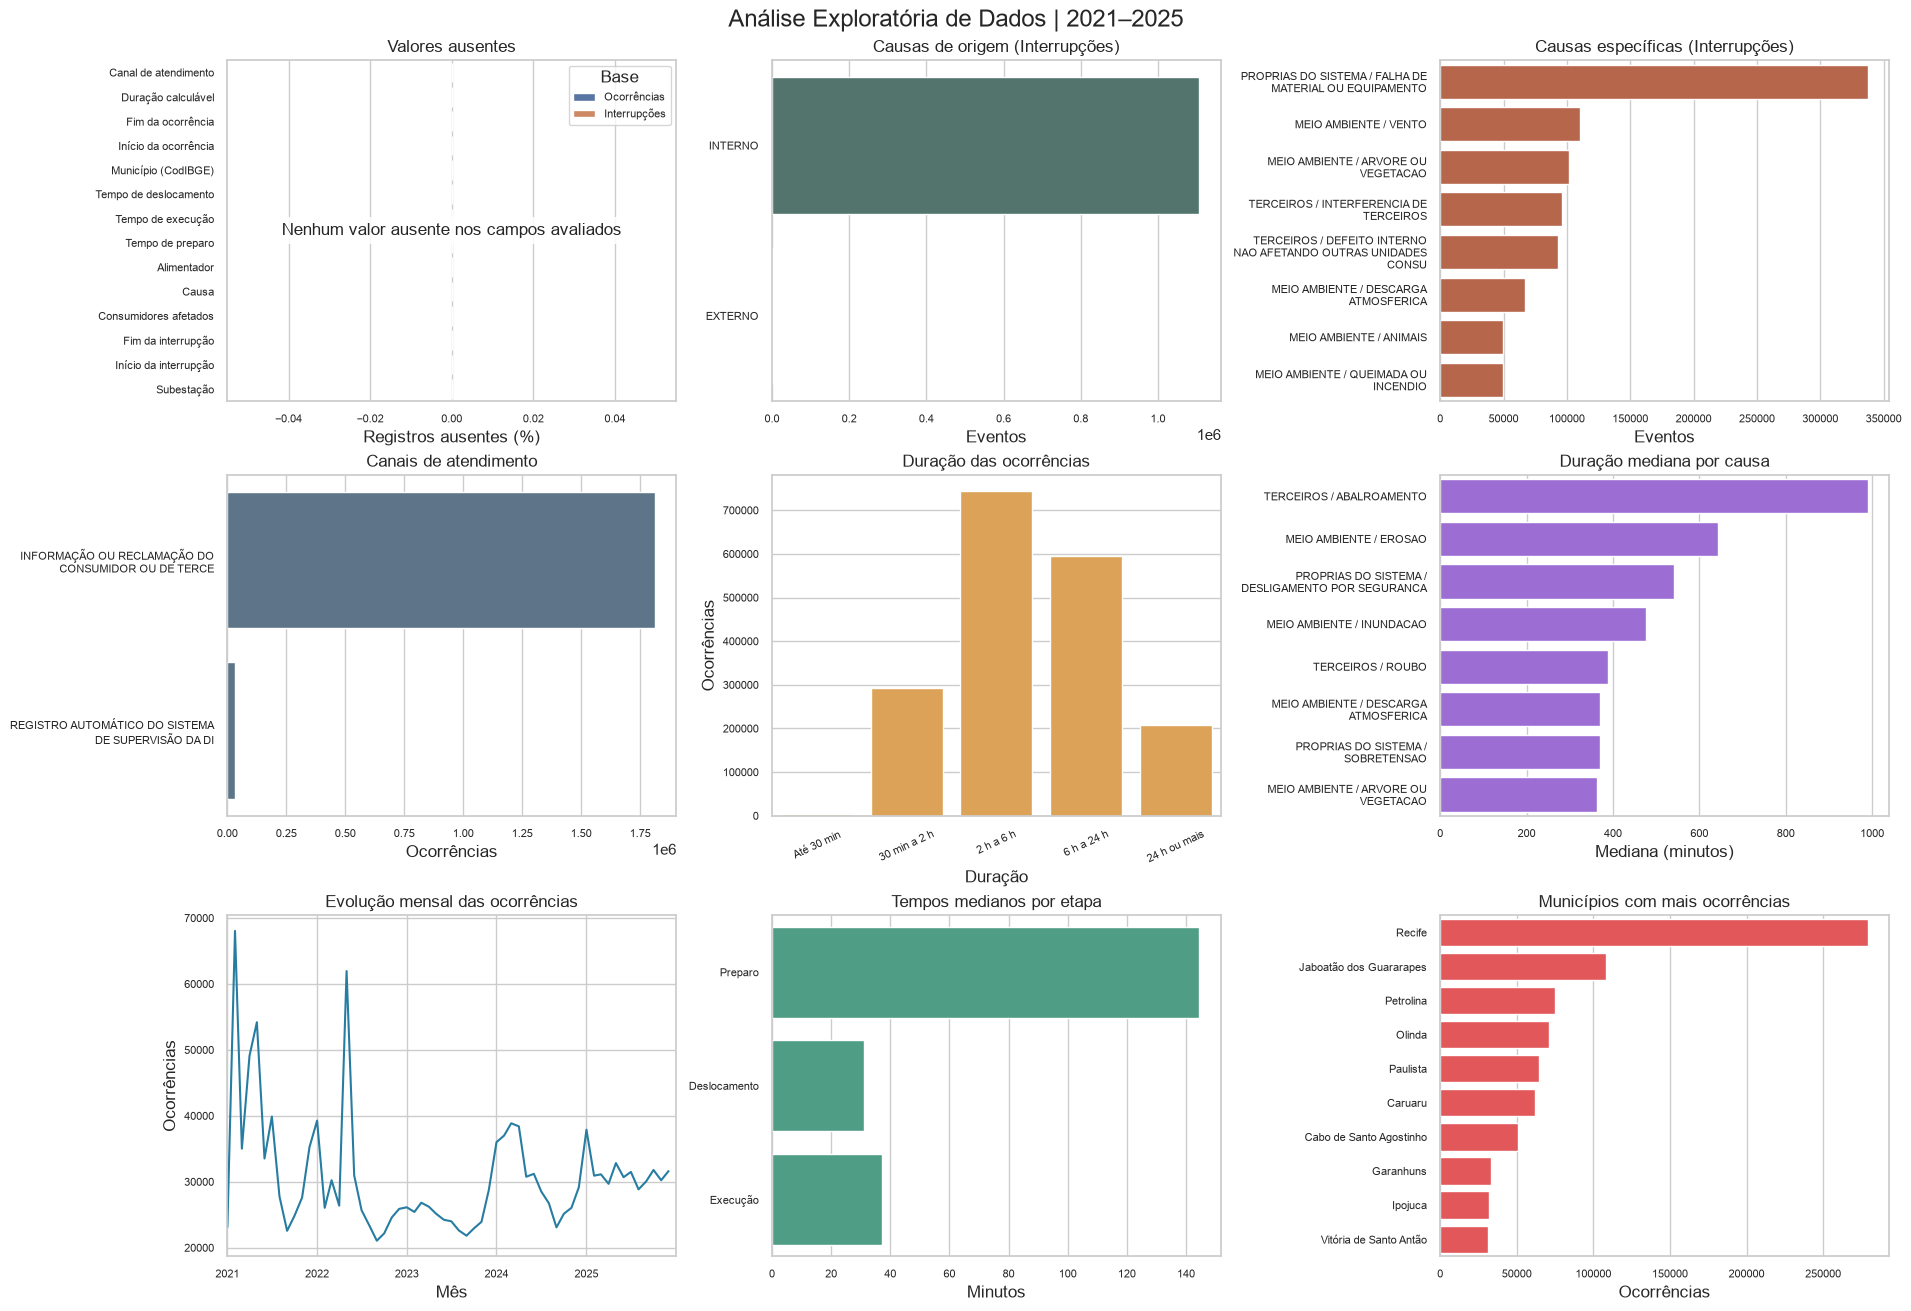

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

query_ausentes_emergencias = """
SELECT c.campo, COUNT(*) AS registros, SUM(c.ausente) AS ausentes
FROM staging.ocorrencias_emergenciais AS oe
CROSS JOIN LATERAL (VALUES
    ('Início da ocorrência', (oe.dth_inicio_ocorrencia_aberta IS NULL)::int),
    ('Fim da ocorrência', (oe.dth_fim_ocorrencia_aberta IS NULL)::int),
    ('Canal de atendimento', (NULLIF(BTRIM(oe.dsc_canal_atendimento), '') IS NULL)::int),
    ('Município (CodIBGE)', (NULLIF(BTRIM(oe.cod_ibge), '') IS NULL)::int),
    ('Tempo de preparo', (oe.mda_preparo IS NULL)::int),
    ('Tempo de deslocamento', (oe.mda_deslocamento IS NULL)::int),
    ('Tempo de execução', (oe.mda_execucao IS NULL)::int),
    ('Duração calculável', ((oe.dth_inicio_ocorrencia_aberta IS NULL OR oe.dth_fim_ocorrencia_aberta IS NULL))::int)
) AS c(campo, ausente)
WHERE oe.ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY c.campo
"""
query_ausentes_interrupcoes = """
SELECT c.campo, COUNT(*) AS registros, SUM(c.ausente) AS ausentes
FROM staging.interrupcoes AS i
CROSS JOIN LATERAL (VALUES
    ('Início da interrupção', (i.dat_inicio_interrupcao IS NULL)::int),
    ('Fim da interrupção', (i.dat_fim_interrupcao IS NULL)::int),
    ('Causa', (NULLIF(BTRIM(i.dsc_fato_gerador_interrupcao), '') IS NULL)::int),
    ('Consumidores afetados', (i.num_unidade_consumidora IS NULL)::int),
    ('Subestação', (NULLIF(BTRIM(i.dsc_subestacao_distribuicao), '') IS NULL)::int),
    ('Alimentador', (NULLIF(BTRIM(i.dsc_alimentador_subestacao), '') IS NULL)::int)
) AS c(campo, ausente)
WHERE i.ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY c.campo
"""
df_ausentes = pd.concat([
    pd.read_sql_query(query_ausentes_emergencias, engine).assign(base="Ocorrências"),
    pd.read_sql_query(query_ausentes_interrupcoes, engine).assign(base="Interrupções"),
], ignore_index=True)
df_ausentes["percentual_ausente"] = 100 * df_ausentes["ausentes"] / df_ausentes["registros"]

query_origens = """
SELECT COALESCE(NULLIF(BTRIM(split_part(dsc_fato_gerador_interrupcao, ' - ', 1)), ''), 'Não informado') AS origem,
       COUNT(*) AS eventos
FROM staging.interrupcoes
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY 1 ORDER BY eventos DESC LIMIT 8
"""
df_origens = pd.read_sql_query(query_origens, engine)

query_causas_especificas = """
SELECT COALESCE(
           NULLIF(BTRIM(split_part(dsc_fato_gerador_interrupcao, ' - ', 3)), '')
           || ' / ' ||
           NULLIF(BTRIM(split_part(dsc_fato_gerador_interrupcao, ' - ', 4)), ''),
           'Não informado'
       ) AS causa_especifica,
       COUNT(*) AS eventos
FROM staging.interrupcoes
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY 1 ORDER BY eventos DESC LIMIT 8
"""
df_causas_especificas = pd.read_sql_query(query_causas_especificas, engine)

df_canais = pd.read_sql_query("""
SELECT COALESCE(NULLIF(BTRIM(dsc_canal_atendimento), ''), 'Não informado') AS canal,
       COUNT(*) AS ocorrencias
FROM staging.ocorrencias_emergenciais
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY 1 ORDER BY ocorrencias DESC LIMIT 8
""", engine)

def quebrar_rotulo(valor, largura=30):
    return "\n".join(textwrap.wrap(str(valor), width=largura))

df_causas_especificas["rotulo_plot"] = df_causas_especificas["causa_especifica"].map(quebrar_rotulo)
df_canais["rotulo_plot"] = df_canais["canal"].map(quebrar_rotulo)

query_duracao_faixas = """
WITH duracoes AS (
    SELECT EXTRACT(EPOCH FROM (dth_fim_ocorrencia_aberta - dth_inicio_ocorrencia_aberta)) / 60.0 AS minutos
    FROM staging.ocorrencias_emergenciais
    WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
      AND dth_inicio_ocorrencia_aberta IS NOT NULL
      AND dth_fim_ocorrencia_aberta IS NOT NULL
      AND dth_fim_ocorrencia_aberta >= dth_inicio_ocorrencia_aberta
), classificadas AS (
    SELECT CASE
        WHEN minutos < 30 THEN 'Até 30 min'
        WHEN minutos < 120 THEN '30 min a 2 h'
        WHEN minutos < 360 THEN '2 h a 6 h'
        WHEN minutos < 1440 THEN '6 h a 24 h'
        ELSE '24 h ou mais'
    END AS faixa,
    CASE
        WHEN minutos < 30 THEN 1
        WHEN minutos < 120 THEN 2
        WHEN minutos < 360 THEN 3
        WHEN minutos < 1440 THEN 4
        ELSE 5
    END AS ordem
    FROM duracoes
)
SELECT faixa, COUNT(*) AS ocorrencias
FROM classificadas
GROUP BY faixa, ordem ORDER BY ordem
"""
df_duracao_faixas = pd.read_sql_query(query_duracao_faixas, engine)

df_duracao_por_causa = pd.read_sql_query("""
WITH duracoes AS (
    SELECT
        COALESCE(
            NULLIF(BTRIM(split_part(dsc_ocorrencia_aberta, ';', 3)), '')
            || ' / ' || NULLIF(BTRIM(split_part(dsc_ocorrencia_aberta, ';', 4)), ''),
            'Não informada'
        ) AS causa_especifica,
        EXTRACT(EPOCH FROM (dth_fim_ocorrencia_aberta - dth_inicio_ocorrencia_aberta)) / 60.0 AS minutos
    FROM staging.ocorrencias_emergenciais
    WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
      AND dth_inicio_ocorrencia_aberta IS NOT NULL
      AND dth_fim_ocorrencia_aberta IS NOT NULL
      AND dth_fim_ocorrencia_aberta >= dth_inicio_ocorrencia_aberta
)
SELECT causa_especifica,
       percentile_cont(0.5) WITHIN GROUP (ORDER BY minutos) AS mediana_minutos,
       COUNT(*) AS ocorrencias
FROM duracoes
GROUP BY causa_especifica
HAVING COUNT(*) >= 100
ORDER BY mediana_minutos DESC
LIMIT 8
""", engine)
df_duracao_por_causa["rotulo_plot"] = df_duracao_por_causa["causa_especifica"].map(quebrar_rotulo)

df_evolucao_mensal = pd.read_sql_query("""
SELECT DATE_TRUNC('month', dth_inicio_ocorrencia_aberta)::date AS mes,
       COUNT(*) AS ocorrencias
FROM staging.ocorrencias_emergenciais
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
  AND dth_inicio_ocorrencia_aberta IS NOT NULL
GROUP BY 1 ORDER BY 1
""", engine)

df_tempos_medianos = pd.read_sql_query("""
SELECT 'Preparo' AS etapa,
       percentile_cont(0.5) WITHIN GROUP (ORDER BY mda_preparo) AS mediana_minutos
FROM staging.ocorrencias_emergenciais
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
UNION ALL
SELECT 'Deslocamento', percentile_cont(0.5) WITHIN GROUP (ORDER BY mda_deslocamento)
FROM staging.ocorrencias_emergenciais
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
UNION ALL
SELECT 'Execução', percentile_cont(0.5) WITHIN GROUP (ORDER BY mda_execucao)
FROM staging.ocorrencias_emergenciais
WHERE ano_arquivo_origem BETWEEN 2021 AND 2025
""", engine)

df_municipios_top = pd.read_sql_query("""
SELECT COALESCE(NULLIF(BTRIM(m.nome_municipio), ''), 'Município não identificado') AS municipio,
       COUNT(*) AS ocorrencias
FROM staging.ocorrencias_emergenciais AS oe
LEFT JOIN dados.municipio AS m ON m.id_municipio = oe.cod_ibge
WHERE oe.ano_arquivo_origem BETWEEN 2021 AND 2025
GROUP BY 1 ORDER BY ocorrencias DESC LIMIT 10
""", engine)

fig, axes = plt.subplots(3, 3, figsize=(19, 13), constrained_layout=True)
fig.suptitle("Análise Exploratória de Dados | 2021–2025", fontsize=17)

sns.barplot(data=df_ausentes, x="percentual_ausente", y="campo", hue="base", ax=axes[0, 0])
axes[0, 0].set_title("Valores ausentes")
axes[0, 0].set_xlabel("Registros ausentes (%)")
axes[0, 0].set_ylabel("")
axes[0, 0].legend(title="Base", fontsize=8)
if df_ausentes["ausentes"].sum() == 0:
    axes[0, 0].text(
        0.5, 0.5, "Nenhum valor ausente nos campos avaliados",
        transform=axes[0, 0].transAxes, ha="center", va="center",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )

sns.barplot(data=df_origens, x="eventos", y="origem", color="#4c7a70", ax=axes[0, 1])
axes[0, 1].set_title("Causas de origem (Interrupções)")
axes[0, 1].set_xlabel("Eventos")
axes[0, 1].set_ylabel("")

sns.barplot(data=df_causas_especificas, x="eventos", y="rotulo_plot", color="#c65d3a", ax=axes[0, 2])
axes[0, 2].set_title("Causas específicas (Interrupções)")
axes[0, 2].set_xlabel("Eventos")
axes[0, 2].set_ylabel("")

sns.barplot(data=df_canais, x="ocorrencias", y="rotulo_plot", color="#577590", ax=axes[1, 0])
axes[1, 0].set_title("Canais de atendimento")
axes[1, 0].set_xlabel("Ocorrências")
axes[1, 0].set_ylabel("")

sns.barplot(data=df_duracao_faixas, x="faixa", y="ocorrencias", color="#f2a541", ax=axes[1, 1])
axes[1, 1].set_title("Duração das ocorrências")
axes[1, 1].set_xlabel("Duração")
axes[1, 1].set_ylabel("Ocorrências")
axes[1, 1].tick_params(axis="x", rotation=25)

sns.barplot(data=df_duracao_por_causa, x="mediana_minutos", y="rotulo_plot", color="#9b5de5", ax=axes[1, 2])
axes[1, 2].set_title("Duração mediana por causa")
axes[1, 2].set_xlabel("Mediana (minutos)")
axes[1, 2].set_ylabel("")

sns.lineplot(data=df_evolucao_mensal, x="mes", y="ocorrencias", color="#277da1", ax=axes[2, 0])
axes[2, 0].set_title("Evolução mensal das ocorrências")
axes[2, 0].set_xlabel("Mês")
axes[2, 0].set_ylabel("Ocorrências")
marcos_anuais = pd.date_range("2021-01-01", "2025-01-01", freq="YS")
axes[2, 0].set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2026-01-01"))
axes[2, 0].set_xticks(marcos_anuais)
axes[2, 0].set_xticklabels([str(ano) for ano in range(2021, 2026)], rotation=0)

sns.barplot(data=df_tempos_medianos, x="mediana_minutos", y="etapa", color="#43aa8b", ax=axes[2, 1])
axes[2, 1].set_title("Tempos medianos por etapa")
axes[2, 1].set_xlabel("Minutos")
axes[2, 1].set_ylabel("")

sns.barplot(data=df_municipios_top, x="ocorrencias", y="municipio", color="#f94144", ax=axes[2, 2])
axes[2, 2].set_title("Municípios com mais ocorrências")
axes[2, 2].set_xlabel("Ocorrências")
axes[2, 2].set_ylabel("")

for eixo in axes.ravel():
    eixo.tick_params(axis="both", labelsize=8)
plt.show()